In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
from coleta import order_payments

In [3]:
order_payments = order_payments.drop_duplicates('order_id')

### Excluindo tipos de pagamentos não definidos

In [4]:
tipos_pagamentos = order_payments[order_payments['payment_type'] != 'not_defined']

- Primeira pergunta de negócio: Quais são as formas de pagamento mais utilizadas?

In [5]:
contagem_por_tipo_pagamento = tipos_pagamentos.groupby('payment_type').agg(quantidade = ('payment_type', 'count')).sort_values(by='quantidade', ascending=False).reset_index()

In [6]:
contagem_por_tipo_pagamento

,payment_type,quantidade
0,credit_card,75387
1,boleto,19784
2,voucher,2739
3,debit_card,1527


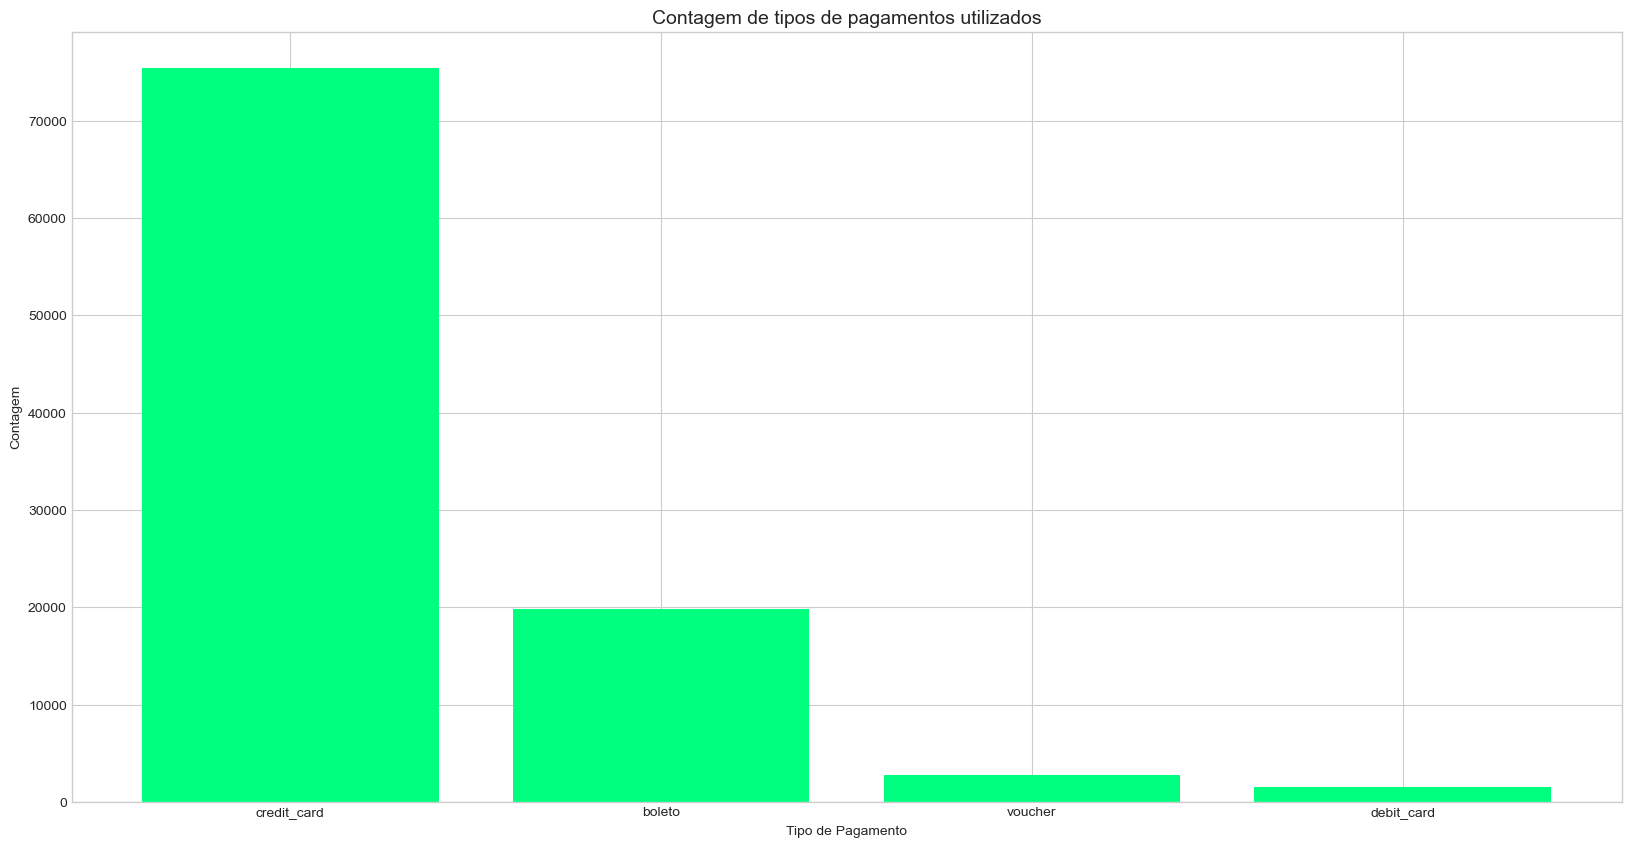

In [7]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(20, 10))
plt.bar(contagem_por_tipo_pagamento['payment_type'], contagem_por_tipo_pagamento['quantidade'], color='springgreen')
plt.xlabel('Tipo de Pagamento')
plt.ylabel('Contagem')
plt.title('Contagem de tipos de pagamentos utilizados', fontsize=14)
plt.show()

    Dentre as formas de pagamentos disponíveis, o cartão de crédito é a mais utilizada, com cerca de 75.387 vendas realizadas com ele.

- Segunda pergunta de negócio: Existe diferença no valor médio dos pedidos entre as formas de pagamento?

In [8]:
valor_medio_tipo_pagamento = tipos_pagamentos.groupby('payment_type').agg(valor_medio = ('payment_value', 'mean')).sort_values(by='valor_medio', ascending=False).reset_index()

In [9]:
valor_medio_tipo_pagamento.head()

,payment_type,valor_medio
0,credit_card,164.733738
1,boleto,145.034435
2,debit_card,142.711061
3,voucher,87.165849


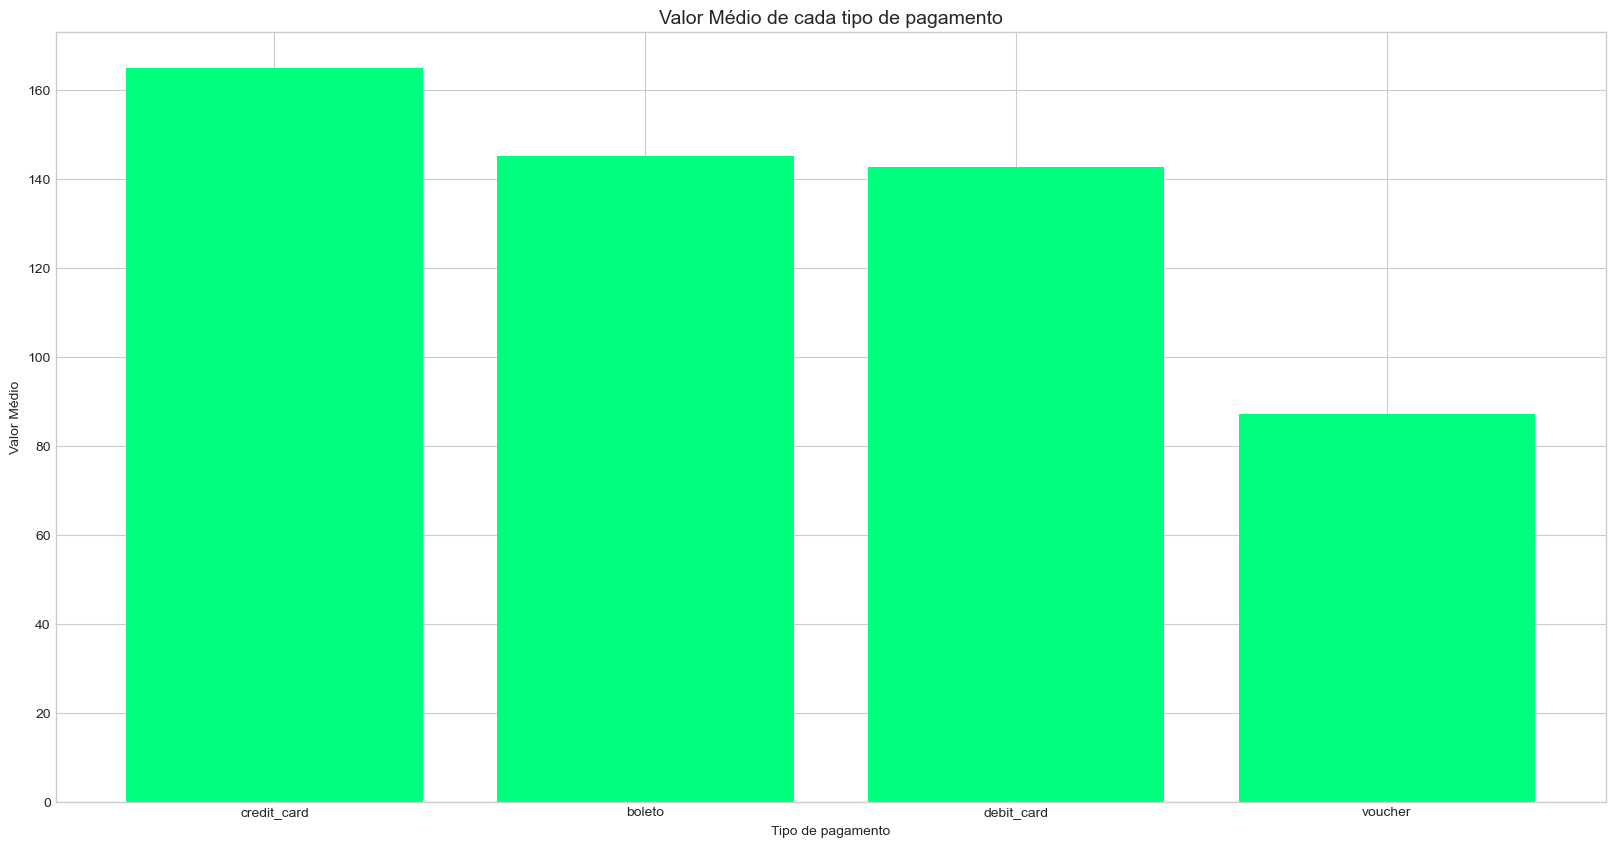

In [10]:
plt.figure(figsize=(20, 10))
plt.bar(valor_medio_tipo_pagamento['payment_type'], valor_medio_tipo_pagamento['valor_medio'], color='springgreen')
plt.xlabel('Tipo de pagamento')
plt.ylabel('Valor Médio')
plt.title('Valor Médio de cada tipo de pagamento', fontsize=14)
plt.show()

    Sim existe uma diferença, a forma de pagamento que tem um maior valor médio de vendas realizadas por ela é o cartão de crédito, seguido do boleto, cartão de débito e voucher.

- Terceira pergunta de negócio: Qual é a participação de cada forma de pagamento no faturamento?

In [11]:
faturamento_total = tipos_pagamentos['payment_value'].sum()

In [12]:
total_tipo_pagamento_sobre_faturamento = tipos_pagamentos.groupby('payment_type').agg(faturamento = ('payment_value', 'sum')).sort_values(by='faturamento', ascending=False).reset_index()

In [13]:
total_tipo_pagamento_sobre_faturamento['participacao'] = total_tipo_pagamento_sobre_faturamento['faturamento'] / faturamento_total

In [14]:
total_tipo_pagamento_sobre_faturamento

,payment_type,faturamento,participacao
0,credit_card,12418782.34,0.788754
1,boleto,2869361.27,0.182242
2,voucher,238747.26,0.015164
3,debit_card,217919.79,0.013841


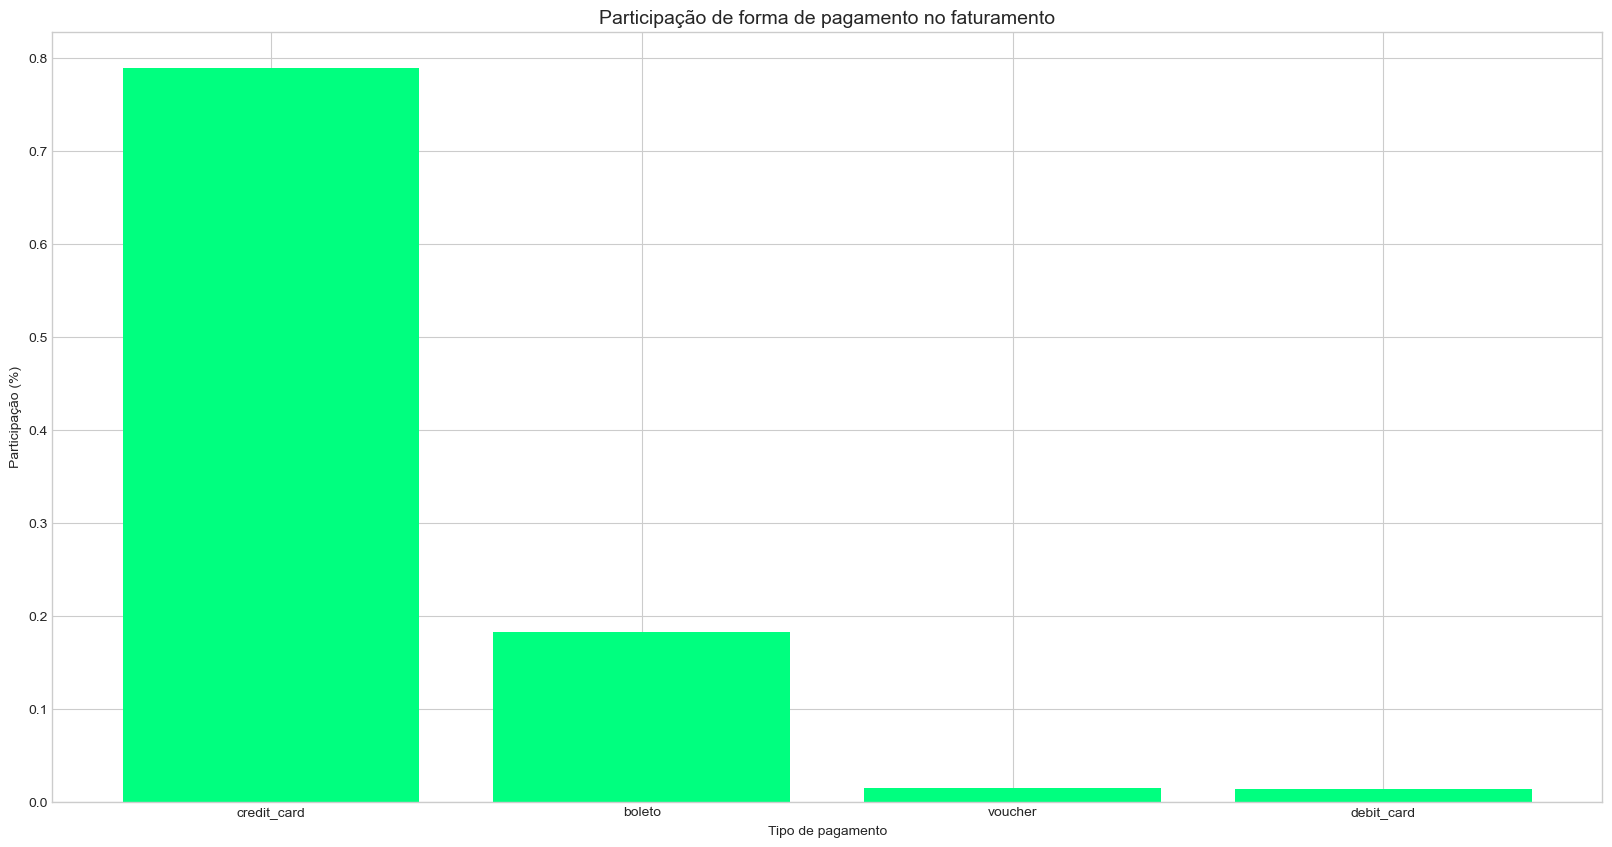

In [15]:
plt.figure(figsize=(20, 10))
plt.bar(total_tipo_pagamento_sobre_faturamento['payment_type'], total_tipo_pagamento_sobre_faturamento['participacao'], color='springgreen')
plt.xlabel('Tipo de pagamento')
plt.ylabel('Participação (%)')
plt.title('Participação de forma de pagamento no faturamento', fontsize=14)
plt.show()

- Quarta pergunta de negócio: O parcelamento está associado a pedidos de maior valor?

In [16]:
correlacao_parcelas_valor = order_payments[['payment_installments', 'payment_value']].corr(method='pearson')

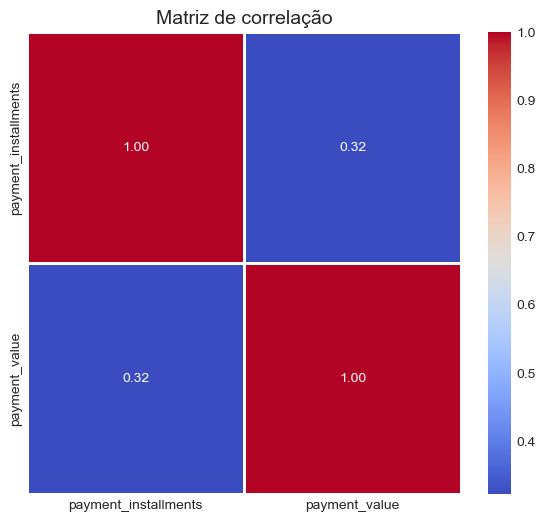

In [17]:
plt.figure(figsize=(7, 6))
sns.heatmap(correlacao_parcelas_valor, annot=True, fmt='.2f', cmap='coolwarm', linewidths=1)
plt.title('Matriz de correlação', fontsize=14)
plt.show()

    Com base na matriz de correlação, observa-se uma relação positiva entre o número de parcelas e o valor das compras. Isso sugere que, à medida que o montante da compra aumenta, cresce também a tendência de o consumidor optar por um maior número de parcelas.